# DataFrame

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv(r"C:\Users\infos\Desktop\GitHub_repositories\employee_attrition_analysis_python\01_Dataset\IBM HR Analytics Employee Attrition & Performance.csv")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

# Analysis

## 1. Attrition Overview:

In [3]:
#Total Employees:
total_employees=len(df)
print(total_employees)

1470


In [4]:
#Attrition Count:
attrition_count=df[df["Attrition"]=="Yes"].shape[0]
print(attrition_count)

237


In [5]:
#Current Employees:
active_employees=total_employees-attrition_count
print(active_employees)

1233


In [6]:
#Attrition Rate(%):
attrition_rate=round((attrition_count/total_employees)*100, 2)
print(attrition_rate)

16.12


In [7]:
#KPI Cards:
print(f"Total Employees: {total_employees:,}")
print(f"Attrition Count: {attrition_count:,}")
print(f"Active Employees:{active_employees:,}")
print(f"Attrition Rate: {attrition_rate}%")

Total Employees: 1,470
Attrition Count: 237
Active Employees:1,233
Attrition Rate: 16.12%


## 2. Income vs Attrition

In [10]:
#Minimum income of an employee
min_income=df["MonthlyIncome"].min()
print(min_income)

1009


In [11]:
#Maximum income of an employee
max_income=df["MonthlyIncome"].max()
print(max_income)

19999


In [12]:
#Creating income groups
df["IncomeGroup"]=pd.cut(df["MonthlyIncome"],
bins=[0,3000,6000,9000,12000,15000,25000],
labels=["0-3K","3K-6K","6K-9K","9K-12K","12K-15K","15K+"])

In [13]:
#Attrition count by Income group
income_attrition=pd.crosstab(df["IncomeGroup"],df["Attrition"])
print(income_attrition)

Attrition     No  Yes
IncomeGroup          
0-3K         282  113
3K-6K        453   66
6K-9K        199   24
9K-12K       115   23
12K-15K       56    6
15K+         128    5


In [14]:
#Attrition Rate (%) by Income group
income_attrition_pct=(pd.crosstab(df["IncomeGroup"],df["Attrition"],normalize="index")*100)
print(income_attrition_pct)

Attrition           No        Yes
IncomeGroup                      
0-3K         71.392405  28.607595
3K-6K        87.283237  12.716763
6K-9K        89.237668  10.762332
9K-12K       83.333333  16.666667
12K-15K      90.322581   9.677419
15K+         96.240602   3.759398


Visualization:



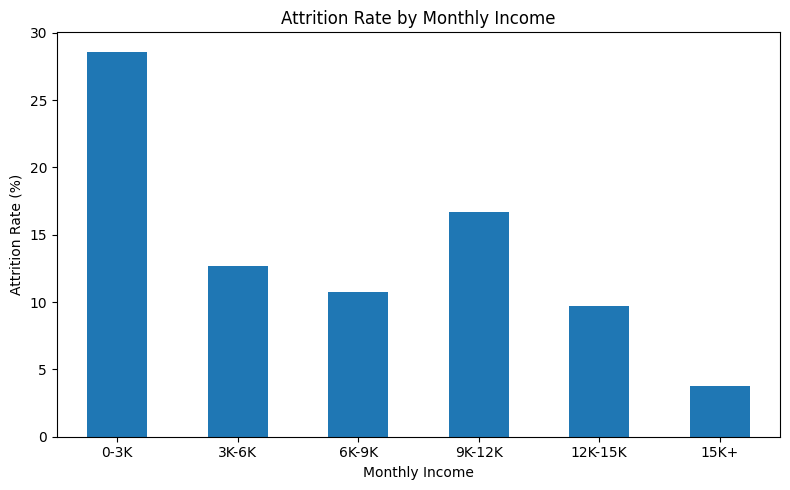

In [16]:
income_attrition_pct["Yes"].plot(kind="bar",figsize=(8,5))
plt.title("Attrition Rate by Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Age Group vs Attrition

In [18]:
#Minimum age of an employee
min_age=df["Age"].min()
print(min_age)

18


In [19]:
#Maximum age of an employee
max_age=df["Age"].max()
print(max_age)

60


In [21]:
#Creating age groups
df["AgeGroup"]=pd.cut(df["Age"],
bins=[18,25,35,45,55,65],
labels=["18-25","26-35","36-45","46-55","56-65"])

In [22]:
#Attrition by age group:
age_attrition=pd.crosstab(df["AgeGroup"],df["Attrition"])
print(age_attrition)

Attrition   No  Yes
AgeGroup           
18-25       75   40
26-35      490  116
36-45      425   43
46-55      200   26
56-65       39    8


In [23]:
#Percentage of Attrition by age group:
age_attrition_pct=pd.crosstab(df["AgeGroup"],df["Attrition"],normalize="index")*100
print(age_attrition_pct)

Attrition         No        Yes
AgeGroup                       
18-25      65.217391  34.782609
26-35      80.858086  19.141914
36-45      90.811966   9.188034
46-55      88.495575  11.504425
56-65      82.978723  17.021277


Visualization

AgeGroup
18-25     40
26-35    116
36-45     43
46-55     26
56-65      8
dtype: int64


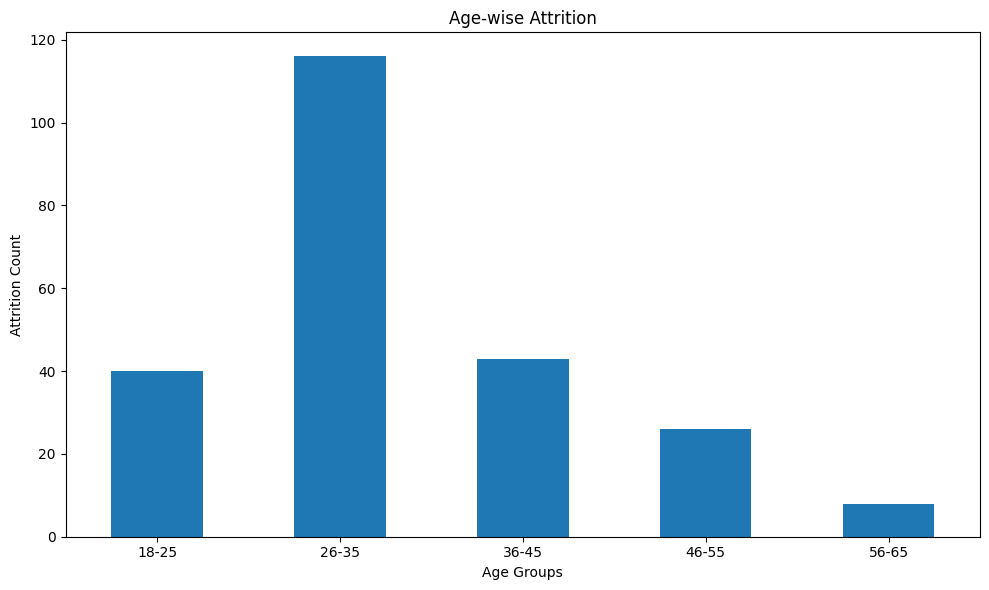

In [25]:
#Age-wise attrition count:
AgeWiseAttrition=(df[df["Attrition"]=="Yes"].groupby("AgeGroup").size())
print(AgeWiseAttrition)

#Chart:
AgeWiseAttrition.plot(kind="bar",figsize=(10,6))
plt.title("Age-wise Attrition")
plt.xticks(rotation=0)
plt.xlabel("Age Groups")
plt.ylabel("Attrition Count")
plt.tight_layout()
plt.show()

## 4. Tenure vs Attrition

In [32]:
#Minimum tenure
min_tenure=df["YearsAtCompany"].min()
print(min_tenure)

0


In [34]:
#Maximum tenure
max_tenure=df["YearsAtCompany"].max()
print(max_tenure)

40


In [35]:
#Creating tenure groups
df["YearsAtCompanyGroup"]=pd.cut(df["YearsAtCompany"],
bins=[0,2,5,10,20,40],
labels=["0-2","3-5","6-10","11-20","21+"])

df["YearsAtCompanyGroup"].head()

0    6-10
1    6-10
2     NaN
3    6-10
4     0-2
Name: YearsAtCompanyGroup, dtype: category
Categories (5, str): ['0-2' < '3-5' < '6-10' < '11-20' < '21+']

In [36]:
#Attrition by tenure groups:
tenure_attrition=pd.crosstab(df["YearsAtCompanyGroup"],df["Attrition"])
print(tenure_attrition )

Attrition             No  Yes
YearsAtCompanyGroup          
0-2                  212   86
3-5                  374   60
6-10                 393   55
11-20                168   12
21+                   58    8


In [37]:
#Attrition percentage by age groups
years_attrition_pct=pd.crosstab(df["YearsAtCompanyGroup"],df["Attrition"],normalize="index")*100
print(years_attrition_pct)

Attrition                   No        Yes
YearsAtCompanyGroup                      
0-2                  71.140940  28.859060
3-5                  86.175115  13.824885
6-10                 87.723214  12.276786
11-20                93.333333   6.666667
21+                  87.878788  12.121212


Visualization

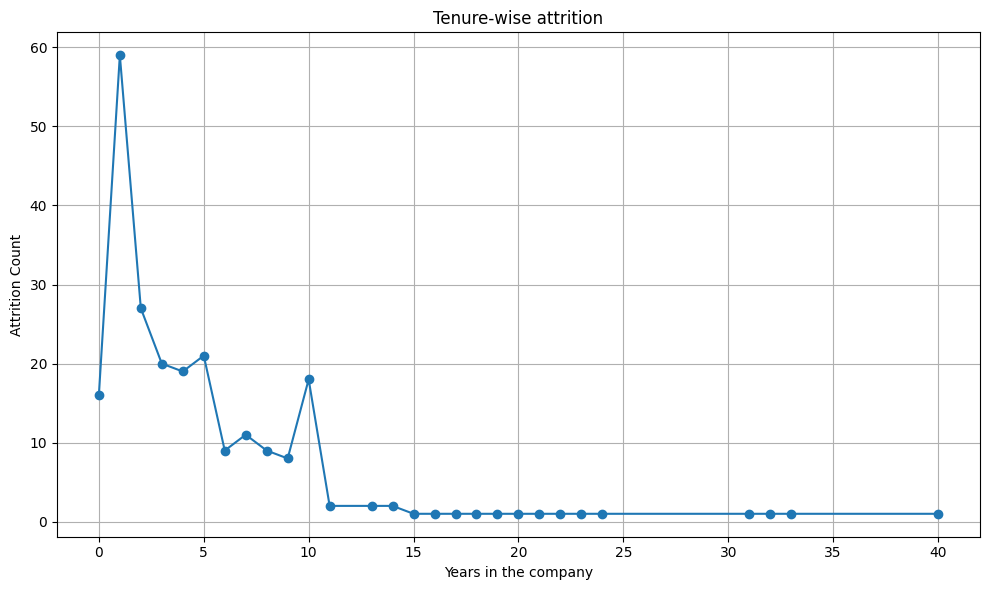

In [41]:
#Tenure-wise attrition count:
TenureWiseAttrition=df[df["Attrition"]=="Yes"].groupby("YearsAtCompany").size()

#Chart:
TenureWiseAttrition.plot(kind="line",marker="o",figsize=(10,6))
plt.grid(True)
plt.title("Tenure-wise attrition")
plt.xlabel("Years in the company")
plt.ylabel("Attrition Count")
plt.tight_layout()
plt.show()

## 5. Job Role vs Attrition

In [44]:
#Type of job roles
df["JobRole"].unique()

<StringArray>
[          'Sales Executive',        'Research Scientist',
     'Laboratory Technician',    'Manufacturing Director',
 'Healthcare Representative',                   'Manager',
      'Sales Representative',         'Research Director',
           'Human Resources']
Length: 9, dtype: str

In [45]:
#Number of employees in every role
df["JobRole"].value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

In [46]:
#Job role-wise attrition count:
jobrole_attrition=pd.crosstab(df["JobRole"],df["Attrition"])
print(jobrole_attrition)

Attrition                   No  Yes
JobRole                            
Healthcare Representative  122    9
Human Resources             40   12
Laboratory Technician      197   62
Manager                     97    5
Manufacturing Director     135   10
Research Director           78    2
Research Scientist         245   47
Sales Executive            269   57
Sales Representative        50   33


In [48]:
#Job role wise attrition percentage:
jobrole_attrition_pct=pd.crosstab(df["JobRole"],df["Attrition"],normalize="index")*100
print(jobrole_attrition_pct)

Attrition                         No        Yes
JobRole                                        
Healthcare Representative  93.129771   6.870229
Human Resources            76.923077  23.076923
Laboratory Technician      76.061776  23.938224
Manager                    95.098039   4.901961
Manufacturing Director     93.103448   6.896552
Research Director          97.500000   2.500000
Research Scientist         83.904110  16.095890
Sales Executive            82.515337  17.484663
Sales Representative       60.240964  39.759036


Visualization

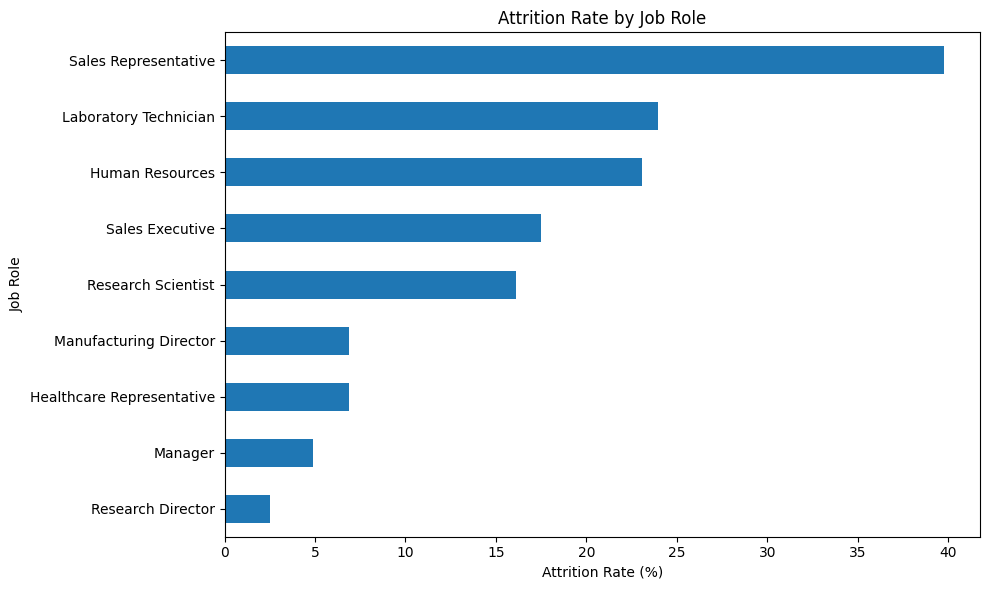

In [49]:
jobrole_attrition_pct["Yes"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")
plt.ylabel("Job Role")
plt.tight_layout()
plt.show()

## 6. Department vs Attrition

In [ ]:
#Department-wise total employee
df["Department"].value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

In [52]:
#Department-wise attrition:
dept_attrition=pd.crosstab(df["Department"],df["Attrition"])
print(dept_attrition)

Attrition                No  Yes
Department                      
Human Resources          51   12
Research & Development  828  133
Sales                   354   92


In [53]:
#Department-wise attrition percentage:
dept_attrition_pct=pd.crosstab(df["Department"],df["Attrition"],normalize="index")*100
print(dept_attrition_pct)

Attrition                      No        Yes
Department                                  
Human Resources         80.952381  19.047619
Research & Development  86.160250  13.839750
Sales                   79.372197  20.627803


Visualization

Department
Research & Development    133
Sales                      92
Human Resources            12
dtype: int64


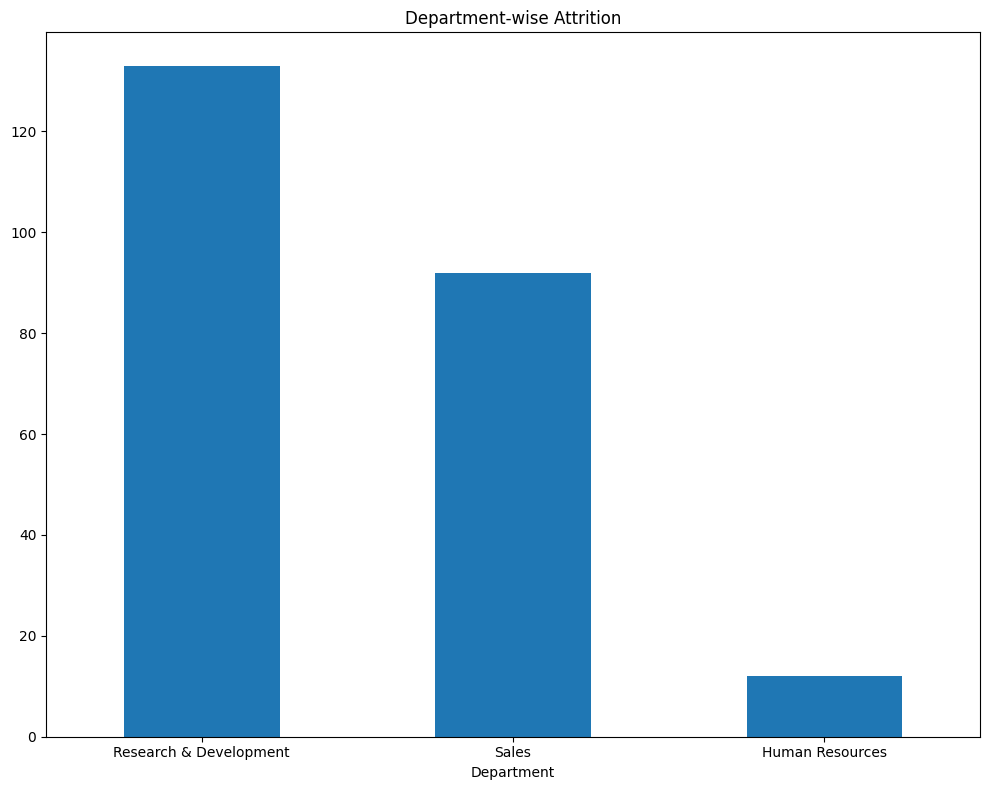

In [54]:
#Department-wise attrition:
dept_attrition=(df[df["Attrition"]=="Yes"].groupby("Department").size().sort_values(ascending=False))
print(dept_attrition)

#Chart:
dept_attrition.plot(kind="bar",figsize=(10,8))
plt.title("Department-wise Attrition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 7. Job Satisfaction vs Attrition

In [60]:
#Job satisfection ratings
df["JobSatisfaction"].value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

In [61]:
#Attrition count by job satisfaction
jobsat_attrition=pd.crosstab(df["JobSatisfaction"],df["Attrition"])
print(jobsat_attrition)

Attrition         No  Yes
JobSatisfaction          
1                223   66
2                234   46
3                369   73
4                407   52


In [62]:
#Attrition Rate (%) by Job Satisfaction
jobsat_attrition_pct=(pd.crosstab(df["JobSatisfaction"],df["Attrition"],normalize="index")*100)
print(jobsat_attrition_pct)

Attrition               No        Yes
JobSatisfaction                      
1                77.162630  22.837370
2                83.571429  16.428571
3                83.484163  16.515837
4                88.671024  11.328976


Visualization

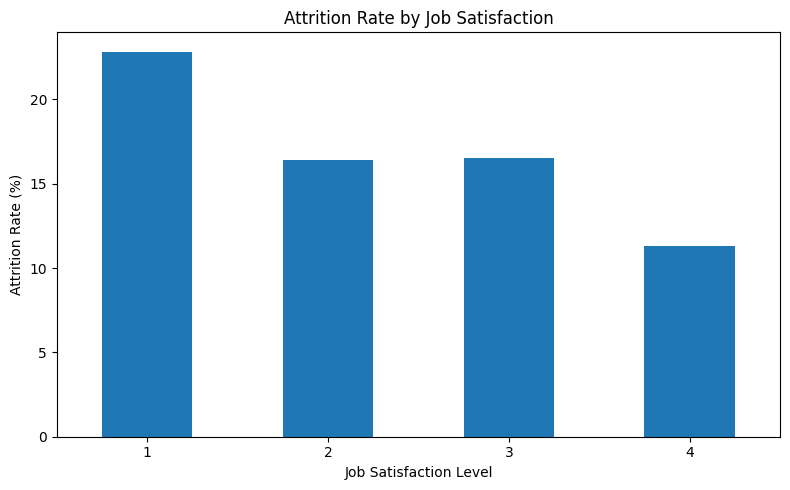

In [63]:
jobsat_attrition_pct["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Job Satisfaction")
plt.xlabel("Job Satisfaction Level")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Overtime vs Attrition


In [67]:
#Overtime by employees
total_overtime=df.groupby("OverTime").size()
print(total_overtime)

OverTime
No     1054
Yes     416
dtype: int64


In [69]:
#Employees who left in each overtime group
attrition_overtime=df[df["Attrition"]=="Yes"].groupby("OverTime").size()
print(attrition_overtime)

OverTime
No     110
Yes    127
dtype: int64


In [70]:
#Attrition Rate
attrition_rate=(attrition_overtime/total_overtime*100).round(2)
print(attrition_rate)

#This means employees working overtime leave at nearly 3 times the rate of those who do not.

OverTime
No     10.44
Yes    30.53
dtype: float64


Visualization

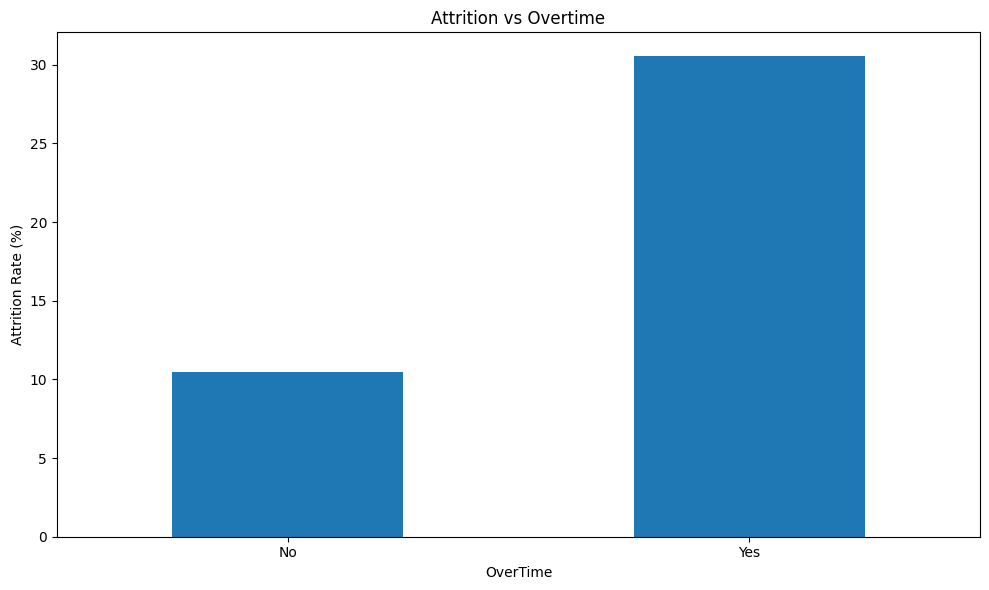

In [71]:
#Attrition vs Overtime:
attrition_rate.plot(kind="bar",figsize=(10,6))

plt.title("Attrition vs Overtime")
plt.xlabel("OverTime")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Gender vs Attrition

In [72]:
#Attrition by gender
gender_attrition=pd.crosstab(df["Gender"],df["Attrition"])
print(gender_attrition)

Attrition   No  Yes
Gender             
Female     501   87
Male       732  150


In [73]:
#Percentage
gender_attrition_pct=(pd.crosstab(df["Gender"],df["Attrition"],normalize="index")*100).round(2)
print(gender_attrition_pct)

Attrition     No    Yes
Gender                 
Female     85.20  14.80
Male       82.99  17.01


Visualization

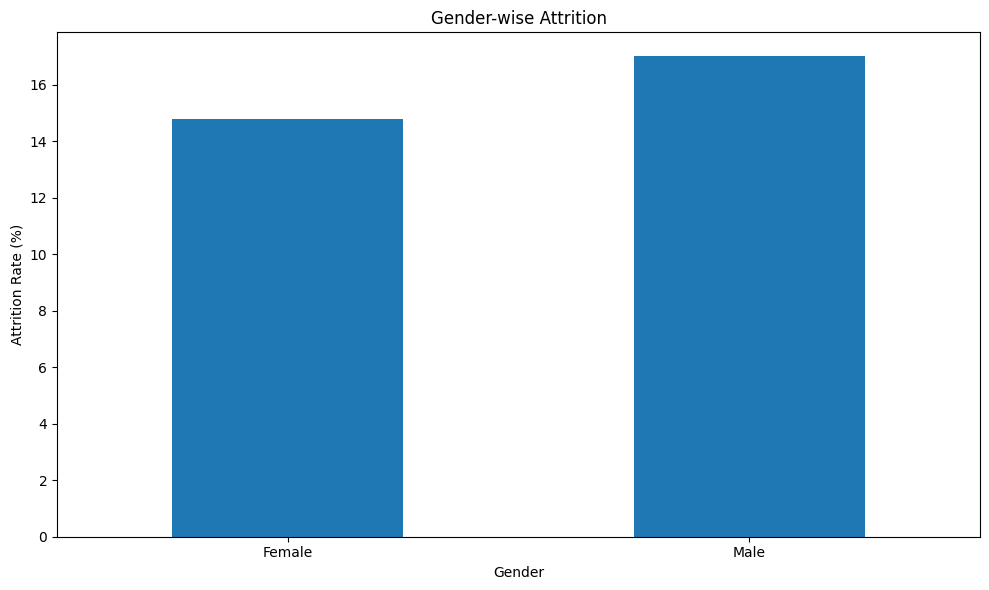

In [74]:
gender_attrition_pct["Yes"].plot(kind="bar",figsize=(10,6))

plt.title("Gender-wise Attrition")
plt.xlabel("Gender")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Work-Life Balance vs Attrition


In the IBM HR dataset, WorkLifeBalance is typically rated from 1 to 4:

| Rating | Meaning |
| ------ | ------- |
| 1      | Bad     |
| 2      | Good    |
| 3      | Better  |
| 4      | Best    |


In [75]:
#Work life balance vd Attrition
wlb_attrition=pd.crosstab(df["WorkLifeBalance"],df["Attrition"])
print(wlb_attrition)

Attrition         No  Yes
WorkLifeBalance          
1                 55   25
2                286   58
3                766  127
4                126   27


In [76]:
wlb_attrition_pct=(pd.crosstab(df["WorkLifeBalance"],df["Attrition"],normalize="index")*100).round(2)
print(wlb_attrition_pct)

Attrition           No    Yes
WorkLifeBalance              
1                68.75  31.25
2                83.14  16.86
3                85.78  14.22
4                82.35  17.65


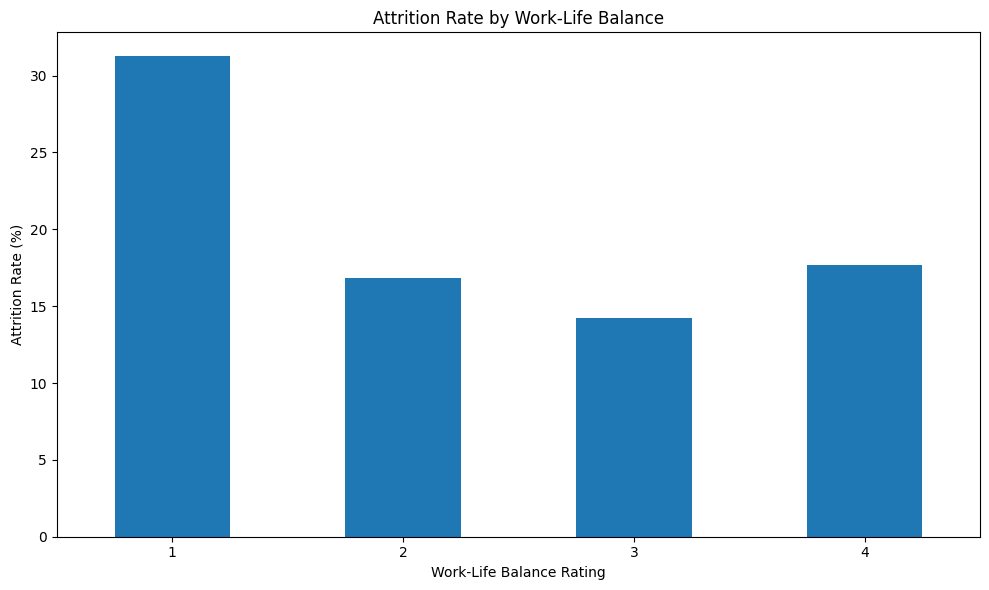

In [77]:
wlb_attrition_pct["Yes"].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 11. Salary Hike vs Attrition


In [ ]:
#Salary hike of employees
df["PercentSalaryHike"].value_counts()

PercentSalaryHike
11    210
13    209
14    201
12    198
15    101
18     89
17     82
16     78
19     76
22     56
20     55
21     48
23     28
24     21
25     18
Name: count, dtype: int64

In [80]:
#Attrition Count by Salary Hike
salaryhike_attrition=pd.crosstab(df["PercentSalaryHike"],df["Attrition"])
print(salaryhike_attrition)

Attrition           No  Yes
PercentSalaryHike          
11                 169   41
12                 165   33
13                 175   34
14                 177   24
15                  83   18
16                  64   14
17                  68   14
18                  76   13
19                  67    9
20                  48    7
21                  43    5
22                  44   12
23                  22    6
24                  15    6
25                  17    1


In [83]:
#Attrition Rate (%) by Salary Hike
salaryhike_attrition_pct=(pd.crosstab(df["PercentSalaryHike"],df["Attrition"],normalize="index")*100).round(2)
print(salaryhike_attrition_pct)

Attrition             No    Yes
PercentSalaryHike              
11                 80.48  19.52
12                 83.33  16.67
13                 83.73  16.27
14                 88.06  11.94
15                 82.18  17.82
16                 82.05  17.95
17                 82.93  17.07
18                 85.39  14.61
19                 88.16  11.84
20                 87.27  12.73
21                 89.58  10.42
22                 78.57  21.43
23                 78.57  21.43
24                 71.43  28.57
25                 94.44   5.56


In [84]:
#Individual salary hike percentages can be noisy, grouping them to makes the analysis easier.
df["SalaryHikeBand"]=pd.cut(df["PercentSalaryHike"],
bins=[10, 15, 20, 25],
labels=["11-15%", "16-20%", "21-25%"])

In [85]:
#Attrition Rate by Salary Hike Band
salary_band_attrition_pct=(pd.crosstab(df["SalaryHikeBand"],df["Attrition"],normalize="index")*100).round(2)
print(salary_band_attrition_pct)

Attrition          No    Yes
SalaryHikeBand              
11-15%          83.68  16.32
16-20%          85.00  15.00
21-25%          82.46  17.54


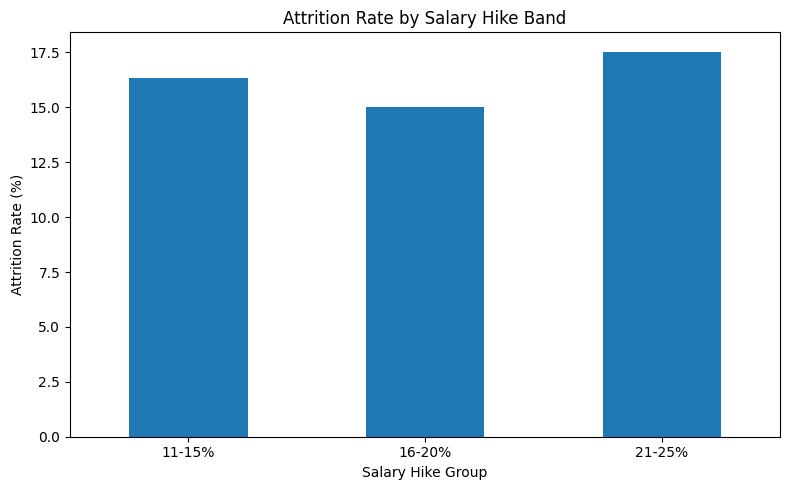

In [86]:
salary_band_attrition_pct["Yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Attrition Rate by Salary Hike Band")
plt.xlabel("Salary Hike Group")
plt.ylabel("Attrition Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()